<h1 style='color:green'>Principal Component Analysis</h1>

[View the PDF](./006-Principal-Component-Analysis.pdf)

In [14]:
from IPython.display import IFrame
IFrame("006-Principal-Component-Analysis.pdf", width=700, height=700)

In [16]:
import numpy as np 
import pandas as pd 

import warnings
warnings.filterwarnings('ignore')

In [26]:
from sklearn.datasets import load_breast_cancer

In [28]:
breast = load_breast_cancer()

In [30]:
X = breast['data']

In [32]:
X.shape

(569, 30)

### Step 1

In [61]:
# mean centering 
mu = X.mean(axis=0)
X_ = X-mu

In [63]:
X_.shape

(569, 30)

### Step-2 

In [68]:
#Covariance Matrix 
S = np.dot(X_.T, X_)

In [72]:
S.shape

(30, 30)

### Step-3 

In [76]:
lamdas, vectors = np.linalg.eig(S) 

In [78]:
lamdas.shape

(30,)

In [82]:
lamdas[:2] #Top 2 lamda 

array([2.52068520e+08, 4.15213684e+06])

In [88]:
vectors.shape  # Vectors are column wise

(30, 30)

In [149]:
vectors[:, 0] #1st eigen vector

array([ 5.08623202e-03,  2.19657026e-03,  3.50763298e-02,  5.16826469e-01,
        4.23694535e-06,  4.05260047e-05,  8.19399539e-05,  4.77807775e-05,
        7.07804332e-06, -2.62155251e-06,  3.13742507e-04, -6.50984008e-05,
        2.23634150e-03,  5.57271669e-02, -8.05646029e-07,  5.51918197e-06,
        8.87094462e-06,  3.27915009e-06, -1.24101836e-06, -8.54530832e-08,
        7.15473257e-03,  3.06736622e-03,  4.94576447e-02,  8.52063392e-01,
        6.42005481e-06,  1.01275937e-04,  1.68928625e-04,  7.36658178e-05,
        1.78986262e-05,  1.61356159e-06])

In [98]:
vectors[:, 1] #2nd eigen vector

array([ 9.28705650e-03, -2.88160658e-03,  6.27480827e-02,  8.51823720e-01,
       -1.48194356e-05, -2.68862249e-06,  7.51419574e-05,  4.63501038e-05,
       -2.52430431e-05, -1.61197148e-05, -5.38692831e-05,  3.48370414e-04,
        8.19640791e-04,  7.51112451e-03,  1.49438131e-06,  1.27357957e-05,
        2.86921009e-05,  9.36007477e-06,  1.22647432e-05,  2.89683790e-07,
       -5.68673345e-04, -1.32152605e-02, -1.85961117e-04, -5.19742358e-01,
       -7.68565692e-05, -2.56104144e-04, -1.75471479e-04, -3.05051743e-05,
       -1.57042845e-04, -5.53071662e-05])

### Step 4

In [100]:
V = vectors[:, :2] #Top 2 eigen vector

In [102]:
V.shape

(30, 2)

In [104]:
V

array([[ 5.08623202e-03,  9.28705650e-03],
       [ 2.19657026e-03, -2.88160658e-03],
       [ 3.50763298e-02,  6.27480827e-02],
       [ 5.16826469e-01,  8.51823720e-01],
       [ 4.23694535e-06, -1.48194356e-05],
       [ 4.05260047e-05, -2.68862249e-06],
       [ 8.19399539e-05,  7.51419574e-05],
       [ 4.77807775e-05,  4.63501038e-05],
       [ 7.07804332e-06, -2.52430431e-05],
       [-2.62155251e-06, -1.61197148e-05],
       [ 3.13742507e-04, -5.38692831e-05],
       [-6.50984008e-05,  3.48370414e-04],
       [ 2.23634150e-03,  8.19640791e-04],
       [ 5.57271669e-02,  7.51112451e-03],
       [-8.05646029e-07,  1.49438131e-06],
       [ 5.51918197e-06,  1.27357957e-05],
       [ 8.87094462e-06,  2.86921009e-05],
       [ 3.27915009e-06,  9.36007477e-06],
       [-1.24101836e-06,  1.22647432e-05],
       [-8.54530832e-08,  2.89683790e-07],
       [ 7.15473257e-03, -5.68673345e-04],
       [ 3.06736622e-03, -1.32152605e-02],
       [ 4.94576447e-02, -1.85961117e-04],
       [ 8.

### Projection

In [114]:
X_.shape

(569, 30)

In [116]:
V.shape

(30, 2)

In [124]:
X_new = np.dot(X_, V)  # (569, 2)  So, 30D->2D

In [128]:
X_new

array([[1160.1425737 , -293.91754364],
       [1269.12244319,   15.63018184],
       [ 995.79388896,   39.15674324],
       ...,
       [ 314.50175618,   47.55352518],
       [1124.85811531,   34.12922497],
       [-771.52762188,  -88.64310636]])

In [170]:
total = sum(lamdas)

In [174]:
explained_variance = np.round(lamdas/total, 3)
explained_variance

array([0.982, 0.016, 0.002, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   ])

In [180]:
explained_variance[:2].sum()

0.998

In [188]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.982, 0.998, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   ])

In [190]:
import matplotlib.pyplot as plt   


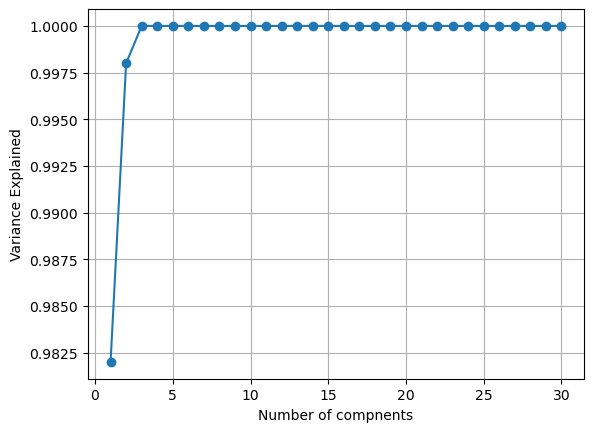

In [198]:
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o")
plt.xlabel('Number of compnents')
plt.ylabel('Variance Explained')
plt.grid('on')

# Using Sklearn

In [141]:
from sklearn.decomposition import PCA 

In [143]:
pca = PCA(n_components=2)

In [145]:
pca.fit_transform(X)

array([[1160.1425737 , -293.91754364],
       [1269.12244319,   15.63018184],
       [ 995.79388896,   39.15674324],
       ...,
       [ 314.50175618,   47.55352518],
       [1124.85811531,   34.12922497],
       [-771.52762188,  -88.64310636]])

<h1 style='color:orange'>Choosing the right dimensions</h1> 

In [160]:
from sklearn.decomposition import PCA 

In [162]:
pca = PCA(n_components=2)

In [164]:
pca.fit_transform(X)

array([[1160.1425737 , -293.91754364],
       [1269.12244319,   15.63018184],
       [ 995.79388896,   39.15674324],
       ...,
       [ 314.50175618,   47.55352518],
       [1124.85811531,   34.12922497],
       [-771.52762188,  -88.64310636]])

In [166]:
pca.explained_variance_

array([443782.6051466 ,   7310.10006165])

In [168]:
pca.explained_variance_ratio_

array([0.98204467, 0.01617649])

In [182]:
pca.explained_variance_ratio_.sum()

0.9982211613741734